# Analyse de la Qualité de l'Air — Dataset AirQualityUCI 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.kernel_ridge import KernelRidge
import warnings
warnings.filterwarnings('ignore')

# 1. Analyse Descriptive

In [2]:
# Charger le dataset
Dataset = pd.read_csv("AirQualityUCI.csv", sep=';', decimal=',')

Dataset.head()
Dataset.info()
Dataset.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), str(2)
memory usage: 1.2 MB


Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64

## Structure du dataset

Le dataset contient 9471 observations et 17 variables, dont la majorité sont numériques. Les colonnes `Date` et `Time` sont de type texte.

On observe la présence de valeurs manquantes (environ 114 par colonne). De plus, les colonnes `Unnamed: 15` et `Unnamed: 16` sont vides et seront supprimées.

Ces éléments montrent qu’un prétraitement des données est nécessaire avant l’analyse.


In [3]:
# Remplacer les valeurs manquantes codées en -200
Dataset.replace(-200, np.nan, inplace=True)

# Supprimer les colonnes vides
Dataset = Dataset.drop(columns=["Unnamed: 15", "Unnamed: 16"])

# Vérifier les valeurs manquantes
Dataset.isna().sum()

Date              114
Time              114
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

### Statistiques descriptives

In [4]:
Dataset.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


### Histogrammes des variables

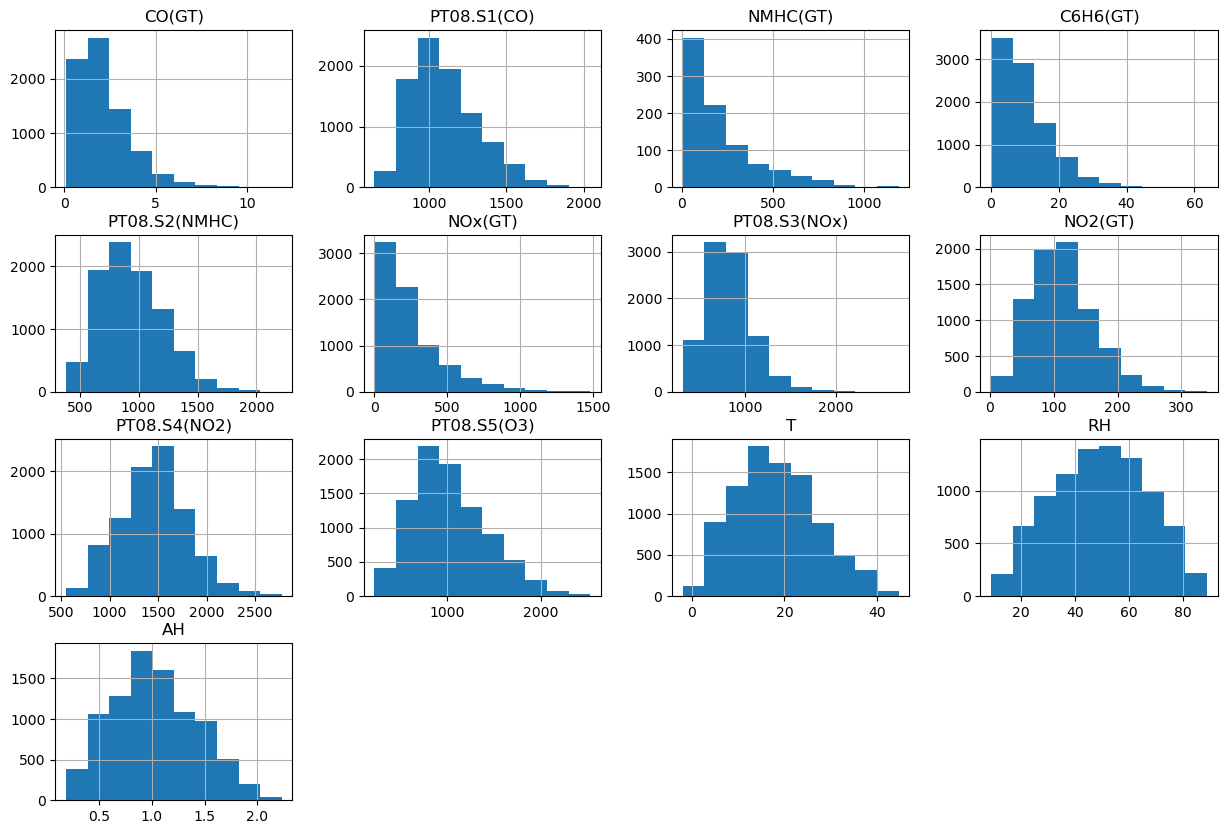

In [5]:
Dataset.hist(figsize=(15,10))
plt.show()

## Distribution des variables

Les histogrammes montrent que la plupart des variables présentent une distribution asymétrique, notamment les polluants (CO, NOx, Benzene), avec une majorité de valeurs faibles et quelques valeurs élevées.

Cela suggère la présence de pics de pollution ponctuels. En revanche, certaines variables comme la température (T) ou l’humidité (RH) ont une distribution plus équilibrée.

Ces différences de distribution devront être prises en compte lors de la modélisation.


### Matrice de corrélation

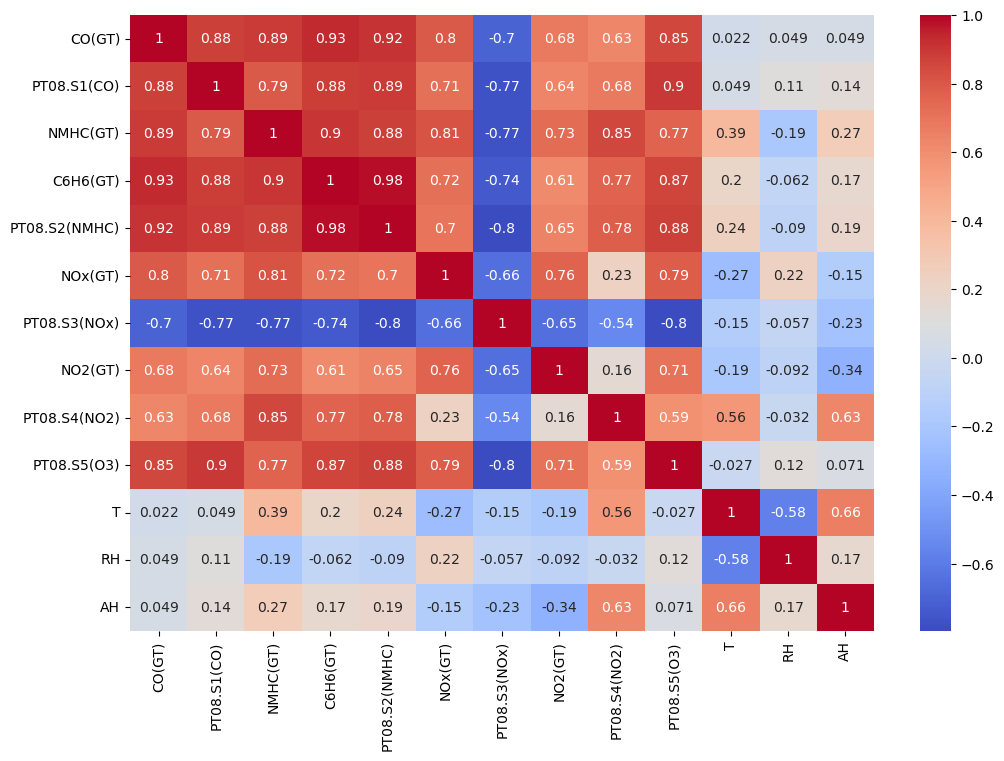

In [6]:
Dataset_numeric = Dataset.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(Dataset_numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

## Analyse des corrélations

La matrice de corrélation montre des relations fortes entre certaines variables. On observe notamment une forte corrélation positive entre les capteurs (PT08) et les concentrations de polluants comme CO, C6H6 et NOx.

Certaines variables présentent également des corrélations négatives, notamment avec le capteur PT08.S3(NOx).

Ces résultats indiquent que les capteurs sont pertinents pour la prédiction des polluants, ce qui sera utile pour la modélisation.


### Boxplots

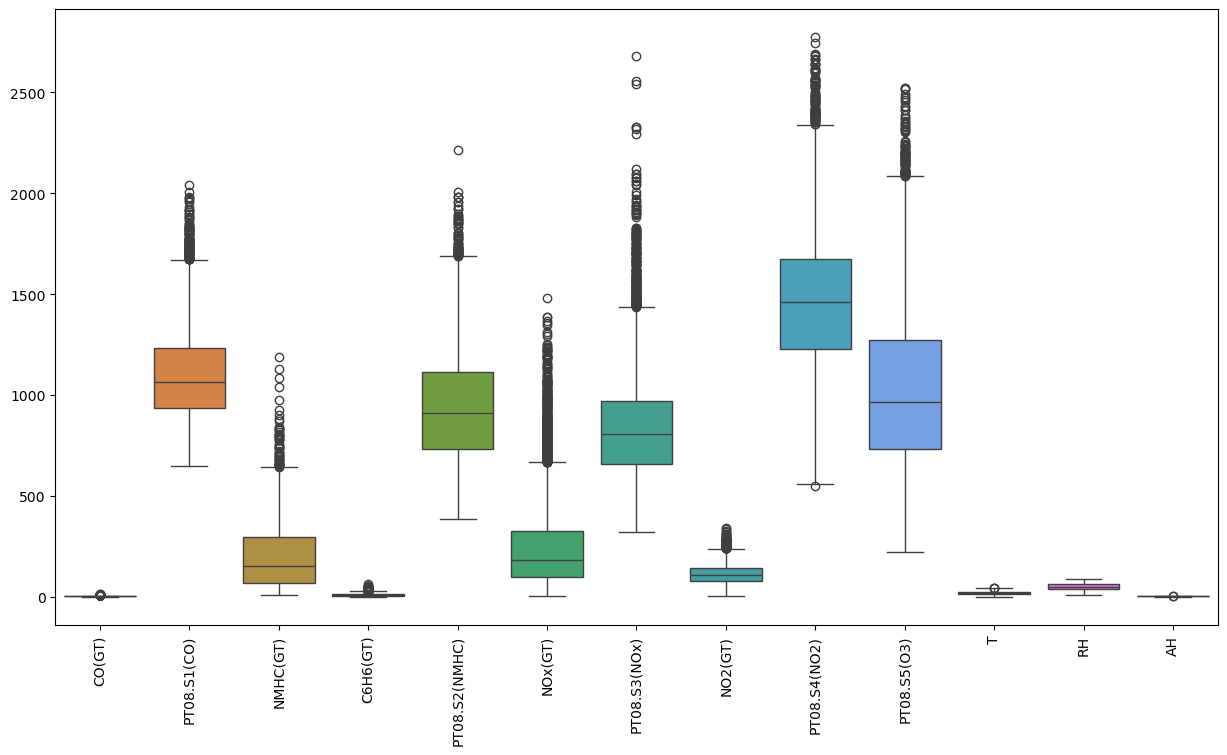

In [7]:
plt.figure(figsize=(15,8))
sns.boxplot(data=Dataset.select_dtypes(include=[np.number]))
plt.xticks(rotation=90)
plt.show()

## Détection des valeurs aberrantes

Les boxplots montrent la présence de nombreuses valeurs aberrantes dans plusieurs variables, notamment les polluants et les capteurs. Cela indique une forte variabilité des données, probablement liée à des pics de pollution.

Les variables environnementales comme la température et l’humidité présentent moins de dispersion.


# 2. Préparation des Données

Les colonnes `Date` et `Time` ont été combinées pour créer une variable temporelle unique. Une correction du format de l'heure a d'abord été nécessaire afin de permettre la conversion en format datetime.

Les données ont ensuite été triées chronologiquement. Enfin, les variables cibles et les variables explicatives ont été définies pour préparer la suite de l'analyse.


In [8]:
# Corriger le format de l'heure
Dataset['Time'] = Dataset['Time'].str.replace('.', ':', regex=False)

# Créer la variable datetime
Dataset['Datetime'] = pd.to_datetime(
    Dataset['Date'] + ' ' + Dataset['Time'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

# Trier les données
Dataset = Dataset.sort_values('Datetime')

# Variables cibles
Y = Dataset[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']]

# Variables explicatives
X = Dataset.drop(columns=['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'Date', 'Time', 'Datetime'])

In [9]:

train_size = int(len(Dataset) * 0.8)

dates_train = Dataset['Datetime'].iloc[:train_size]
dates_test  = Dataset['Datetime'].iloc[train_size:]

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]

Y_train = Y.iloc[:train_size]
Y_test  = Y.iloc[train_size:]

print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(7576, 9) (1895, 9)
(7576, 4) (1895, 4)


In [10]:
'''# Standardisation des données
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)'''
imputer = SimpleImputer(strategy='mean')

X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print(np.isnan(X_train_sc).sum())
print(np.isnan(X_test_sc).sum())

0
0


In [11]:
targets = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

## Séparation des données

Les données ont été divisées en un ensemble d’entraînement (80%) et un ensemble de test (20%) en respectant l’ordre chronologique. Cela permet d’éviter toute fuite d’information et de conserver la structure temporelle des données.



## Kernel Ridge Regression avec Kernel RBF (Gaussien)

### Présentation de la méthode

Le kernel ridge regression cherche à minimiser :

$$
\hat{f}^n_{\mathcal{F}} \in \underset{f \in \mathcal{F}}{\min}\; \frac{1}{n}\sum_{i=1}^n (Y_i - f(X_i))^2 + \lambda\|f\|^2_{\mathcal{F}}
$$

La solution est de la forme $\hat{f}(x) = \sum_{i=1}^n \hat{\alpha}_i\, k(X_i, x)$, avec :

$$
\hat{\alpha} = (K + \lambda n\, I_n)^{-1} Y
$$

Le **kernel RBF (Radial Basis Function)**, aussi appelé kernel gaussien, est défini par :

$$
k(x, y) = \exp\left(-\frac{\|x - y\|^2}{2\sigma^2}\right) = \exp\left(-\gamma \|x - y\|^2\right)
$$

avec $\gamma = \frac{1}{2\sigma^2}$.

Ce kernel mesure la **similarité locale** entre deux points : deux points proches donnent une valeur proche de 1, deux points éloignés donnent une valeur proche de 0. Il correspond à un espace de Hilbert de **dimension infinie**, ce qui lui permet de capturer des relations **non-linéaires** complexes entre X et Y.

### Discussion sur l'influence de $\alpha$ et $\gamma$

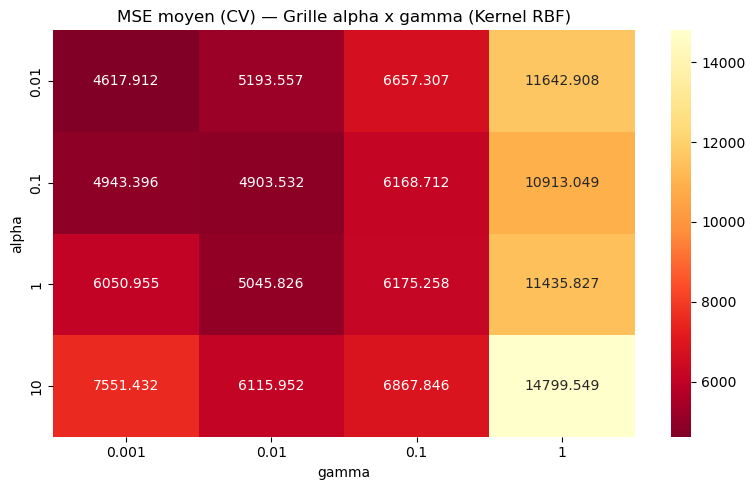

Meilleurs paramètres : alpha=0.01, gamma=0.001
MSE moyen correspondant : 4617.9120


In [12]:
alphas = [0.01, 0.1, 1, 10]
gammas = [0.001, 0.01, 0.1, 1]

tscv = TimeSeriesSplit(n_splits=5)
results_grid = {}

for alpha in alphas:
    for gamma in gammas:
        mse_folds = []
        for train_idx, test_idx in tscv.split(X):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            Y_tr, Y_te = Y.iloc[train_idx], Y.iloc[test_idx]

            sc_cv = StandardScaler()
            X_tr = sc_cv.fit_transform(X_tr)
            X_te = sc_cv.transform(X_te)

            m = KernelRidge(kernel='rbf', alpha=alpha, gamma=gamma)
            # Imputer for missing values in X
            imputer_x = SimpleImputer(strategy='mean')
            X_tr = imputer_x.fit_transform(X_tr)
            X_te = imputer_x.transform(X_te)
            
            # Imputer for missing values in Y
            imputer_y = SimpleImputer(strategy='mean')
            Y_tr = imputer_y.fit_transform(Y_tr)
            Y_te = imputer_y.transform(Y_te)
            
            m.fit(X_tr, Y_tr)
            mse_folds.append(mean_squared_error(Y_te, m.predict(X_te)))

        results_grid[(alpha, gamma)] = np.mean(mse_folds)

# Affichage sous forme de heatmap
grid_matrix = np.array([[results_grid[(a, g)] for g in gammas] for a in alphas])

plt.figure(figsize=(8, 5))
sns.heatmap(
    grid_matrix,
    xticklabels=gammas,
    yticklabels=alphas,
    annot=True, fmt='.3f',
    cmap='YlOrRd_r'
)
plt.xlabel('gamma')
plt.ylabel('alpha')
plt.title('MSE moyen (CV) — Grille alpha x gamma (Kernel RBF)')
plt.tight_layout()
plt.show()

best_params = min(results_grid, key=results_grid.get)
best_alpha, best_gamma = best_params
print(f"Meilleurs paramètres : alpha={best_alpha}, gamma={best_gamma}")
print(f"MSE moyen correspondant : {results_grid[best_params]:.4f}")

In [14]:
model_best = KernelRidge(kernel='rbf', alpha=best_alpha, gamma=best_gamma)
imputer_y = SimpleImputer(strategy='mean')
Y_train_imp = imputer_y.fit_transform(Y_train)
Y_test_imp = imputer_y.transform(Y_test)

model_best.fit(X_train_sc, Y_train_imp)
Y_pred_best = model_best.predict(X_test_sc)

mse_final  = mean_squared_error(Y_test_imp, Y_pred_best)
rmse_final = mean_squared_error(Y_test_imp, Y_pred_best, multioutput='raw_values') ** 0.5

print(f"MSE global (alpha={best_alpha}, gamma={best_gamma}) : {mse_final:.4f}")
print(f"RMSE par variable : {rmse_final}")

# Tableau final
comparaison_final = pd.DataFrame({
    'Variable':  targets,
    'mean':      Y_test[targets].mean().values,
    'std':       Y_test[targets].std().values,
    'RMSE':      rmse_final,
    'RMSE/mean': rmse_final / Y_test[targets].mean().values,
    'RMSE/std':  rmse_final / Y_test[targets].std().values
})
print(comparaison_final.to_string(index=False))
Y_pred_best = model_best.predict(X_test_sc)

mse_final  = mean_squared_error(Y_test_imp, Y_pred_best)
rmse_final = mean_squared_error(Y_test_imp, Y_pred_best, multioutput='raw_values') ** 0.5



MSE global (alpha=0.01, gamma=0.001) : 2570.2540
RMSE par variable : [ 0.7372025   0.45914496 93.51479532 39.18220102]
Variable       mean        std      RMSE  RMSE/mean  RMSE/std
  CO(GT)   1.955038   1.345652  0.737203   0.377078  0.547841
C6H6(GT)   7.803776   6.361743  0.459145   0.058836  0.072173
 NOx(GT) 300.594094 201.678795 93.514795   0.311100  0.463682
 NO2(GT) 143.968153  53.828917 39.182201   0.272159  0.727902


L’erreur relative par rapport à la moyenne reste modérée pour l’ensemble des variables. Elle est d’environ 38% pour CO(GT), 6% pour C6H6(GT), 31% pour NOx(GT) et 27% pour NO2(GT).

Le RMSE standardisé reste inférieur à 1 pour toutes les variables, ce qui montre que le modèle reste globalement correct.

Les meilleurs résultats sont obtenus pour C6H6(GT), tandis que les erreurs sont plus importantes pour NOx(GT) et NO2(GT), ce qui peut s’expliquer par une plus forte variabilité de ces polluants dans le temps.

Dans l’ensemble, le modèle Kernel Ridge avec noyau RBF donne des résultats satisfaisants sur les données de qualité de l’air.


In [17]:
print("Écart-type sur Y_train \n", Y_train.std())
print("Écart-type sur Y_test \n",Y_test.std())

Écart-type sur Y_train 
 CO(GT)        1.477672
C6H6(GT)      7.583505
NOx(GT)     213.651412
NO2(GT)      42.718818
dtype: float64
Écart-type sur Y_test 
 CO(GT)        1.345652
C6H6(GT)      6.361743
NOx(GT)     201.678795
NO2(GT)      53.828917
dtype: float64


Les écarts-types de Y_train et Y_test sont assez proches, ce qui montre que les données d’entraînement et de test ont une variabilité similaire.

Les variables NOx(GT) et NO2(GT) varient davantage dans le temps, ce qui peut expliquer des erreurs de prédiction plus importantes.


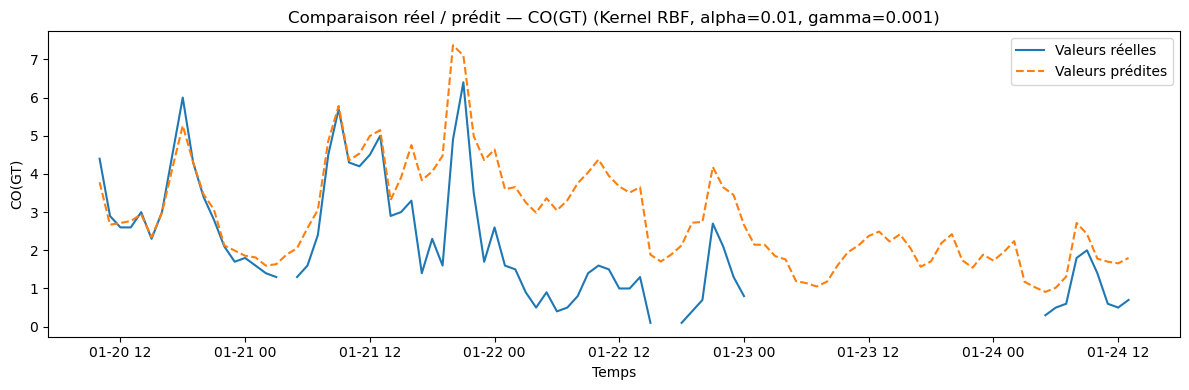

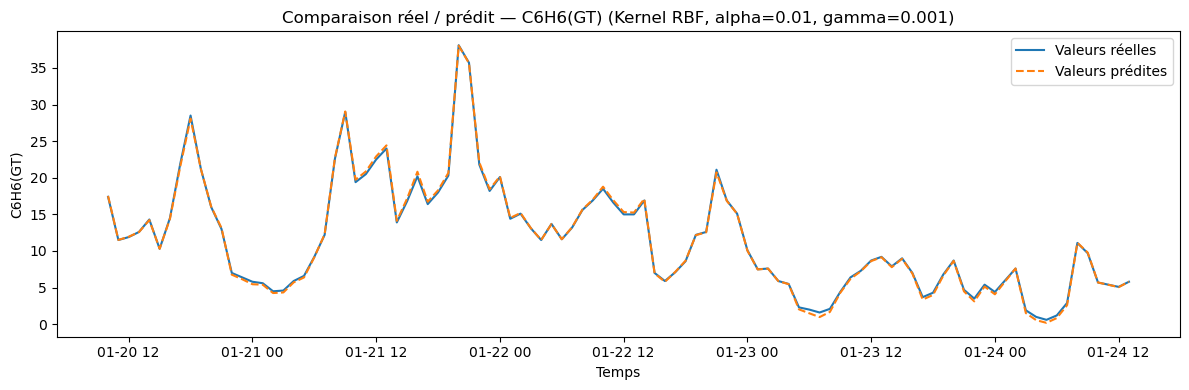

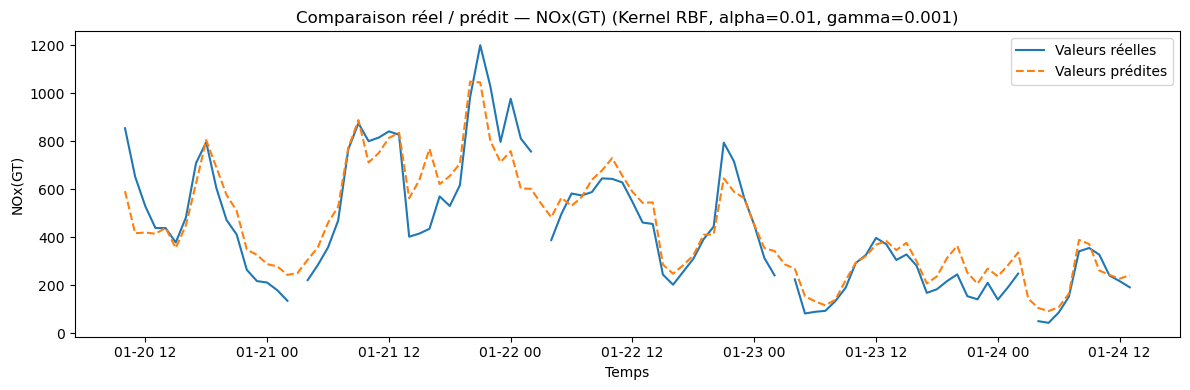

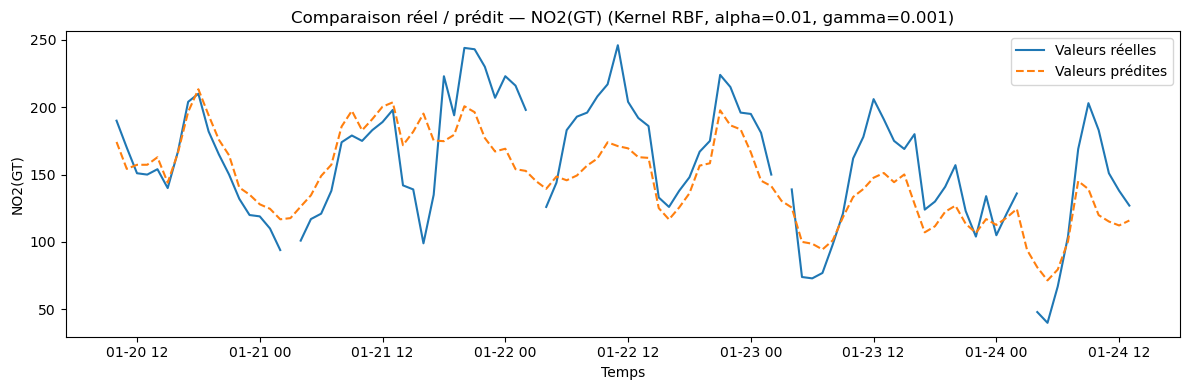

In [15]:
# Visualisation finale
for i, target in enumerate(targets):
    plt.figure(figsize=(12, 4))
    plt.plot(dates_test.values[:100], Y_test[target].values[:100], label="Valeurs réelles")
    plt.plot(dates_test.values[:100], Y_pred_best[:100, i], label="Valeurs prédites", linestyle='--')
    plt.title(f"Comparaison réel / prédit — {target} (Kernel RBF, alpha={best_alpha}, gamma={best_gamma})")
    plt.xlabel("Temps")
    plt.ylabel(target)
    plt.legend()
    plt.tight_layout()
    plt.show()


---
### Analyse de la variabilité avec TimeSeriesSplit

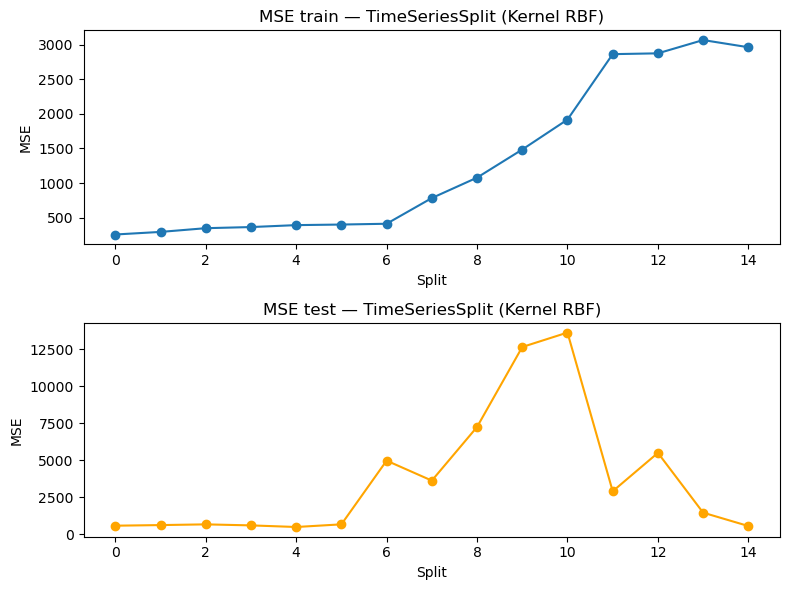

In [16]:
tscv = TimeSeriesSplit(n_splits=15)

mse_train_list = []
mse_test_list  = []

for train_idx, test_idx in tscv.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    Y_tr, Y_te = Y.iloc[train_idx], Y.iloc[test_idx]

    sc_cv = StandardScaler()
    X_tr = sc_cv.fit_transform(X_tr)
    X_te = sc_cv.transform(X_te)

    m = KernelRidge(kernel='rbf', alpha=best_alpha, gamma=best_gamma)
    # Imputer for missing values in X
    imputer_x = SimpleImputer(strategy='mean')
    X_tr = imputer_x.fit_transform(X_tr)
    X_te = imputer_x.transform(X_te)
    
    # Imputer for missing values in Y
    imputer_y = SimpleImputer(strategy='mean')
    Y_tr = imputer_y.fit_transform(Y_tr)
    Y_te = imputer_y.transform(Y_te)

    m.fit(X_tr, Y_tr)

    mse_train_list.append(mean_squared_error(Y_tr, m.predict(X_tr)))
    mse_test_list.append(mean_squared_error(Y_te, m.predict(X_te)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

ax1.plot(mse_train_list, marker='o')
ax1.set_title("MSE train — TimeSeriesSplit (Kernel RBF)")
ax1.set_xlabel("Split")
ax1.set_ylabel("MSE")

ax2.plot(mse_test_list, marker='o', color='orange')
ax2.set_title("MSE test — TimeSeriesSplit (Kernel RBF)")
ax2.set_xlabel("Split")
ax2.set_ylabel("MSE")

plt.tight_layout()
plt.show()

On remarque que les erreurs ne sont pas les mêmes selon les splits. À certains moments, surtout au milieu des graphiques, le MSE test augmente beaucoup. Cela peut venir du fait que les données de pollution changent selon les périodes.

On voit aussi que le MSE test est souvent plus élevé que le MSE train, ce qui montre que le modèle a plus de difficulté sur les données qu’il n’a pas vues.

Malgré ça, les erreurs baissent à nouveau sur les derniers splits, donc le modèle reste quand même correct dans l’ensemble.


### Analyse critique des résultats

Le modèle donne de bons résultats pour C6H6(GT), avec des erreurs relativement faibles. En revanche, les erreurs sont plus élevées pour NOx(GT) et NO2(GT), ce qui peut s’expliquer par leur forte variabilité dans le temps.

On remarque aussi que les performances varient selon les splits du TimeSeriesSplit, ce qui montre que certaines périodes de pollution sont plus difficiles à prédire que d’autres.
